In [8]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import transformers
from transformers import AutoModel, BertTokenizerFast
import matplotlib.pyplot as plt
from src.litmodel import LitModel
import umap

# MPS
if torch.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [9]:
# rna_prot = pd.read_excel("data/1-s2.0-S2666379124002398-mmc3.xlsx", sheet_name="Abundance_gene_MD_protein", engine="calamine")
# metabolomics = pd.read_excel("data/1-s2.0-S2666379124002398-mmc9.xlsx", sheet_name="compound_abundance", engine="calamine")

rna_prot = pd.read_excel(
    "data/kidney/rna_prote_both_tabs1-s2.0-S2666379124002398-mmc3_RNAseqExpressionMX_proteinAbund_exprMX.xlsx",
    sheet_name="Abundance_gene_MD_protein",
    engine="calamine",
)
metabolomics = pd.read_excel(
    "data/kidney/compoundTab_metab_1-s2.0-S2666379124002398-mmc9.xlsx",
    sheet_name="compound_abundance",
    engine="calamine",
)

rna_prot = rna_prot.drop(
    columns=[
        col
        for col in rna_prot.columns
        if not col.endswith("T") and not col.endswith("N")
    ]
)
rna_prot = rna_prot.fillna(rna_prot.median())

metabolomics = metabolomics.drop(columns="Name")
metabolomics = metabolomics.fillna(metabolomics.median())

In [10]:
omic_dict = {}
for col in metabolomics.columns:
    label = 1 if col.endswith("T") else 0
    omic_dict[col] = {}
    omic_dict[col]["m"] = (metabolomics[col].values,)  # This stores the whole array
    omic_dict[col]["label"] = label
    omic_dict[col]["r"] = rna_prot[col].values

In [11]:
#t stands for tumor, n for control
data_list = []

for col in metabolomics.columns:
    label = 1 if col.startswith("T") else 0
    data_list.append({
        "omic_elem": metabolomics[col].values, # This stores the whole array
        "label": label
    })

new_metab = pd.DataFrame(data_list)

In [12]:
data_list = []

for col in rna_prot.columns:
    label = 1 if col.endswith("T") else 0
    data_list.append({
        "omic_elem": rna_prot[col].values, # This stores the whole array
        "label": label
    })

new_rna = pd.DataFrame(data_list)

In [3]:
from src.train_script import get_dataset

In [4]:
train, test, val = get_dataset(fourier=True, batch_size=1)

In [15]:
# pass the pre-trained BERT to our define architecture
model = BERT_Arch_Fourier(bert)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# push the model to GPU
model = model.to(device)

NameError: name 'BERT_Arch_Fourier' is not defined

In [13]:
# function to train the model
def train():

    model.train()
    total_loss, total_accuracy = 0, 0

    # empty list to save model predictions
    total_preds = []

    # iterate over batches
    for step, batch in enumerate(train_dataloader):
        # progress update after every 50 batches.
        if step % 50 == 0 and not step == 0:
            print("  Batch {:>5,}  of  {:>5,}.".format(step, len(train_dataloader)))

        # push the batch to gpu
        batch = [r.to(device) for r in batch]

        sent_id, mask, labels = batch

        # clear previously calculated gradients
        model.zero_grad()

        # get model predictions for the current batch
        preds = model(sent_id, mask)

        # compute the loss between actual and predicted values
        loss = cross_entropy(preds, labels)

        # add on to the total loss
        total_loss = total_loss + loss.item()

        # backward pass to calculate the gradients
        loss.backward()

        # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # update parameters
        optimizer.step()

        # model predictions are stored on GPU. So, push it to CPU
        preds = preds.detach().cpu().numpy()

    # append the model predictions
    total_preds.append(preds)

    # compute the training loss of the epoch
    avg_loss = total_loss / len(train_dataloader)

    # predictions are in the form of (no. of batches, size of batch, no. of classes).
    # reshape the predictions in form of (number of samples, no. of classes)
    total_preds = np.concatenate(total_preds, axis=0)
    # returns the loss and predictions
    return avg_loss, total_preds

In [14]:
import time


# function for evaluating the model
def evaluate():

    print("\nEvaluating...")
    t0 = time.time()
    # deactivate dropout layers
    model.eval()

    total_loss, total_accuracy = 0, 0

    # empty list to save the model predictions
    total_preds = []

    # iterate over batches
    for step, batch in enumerate(val_dataloader):
        # Progress update every 50 batches.
        if step % 50 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = time.time() - t0

            # Report progress.
            print("  Batch {:>5,}  of  {:>5,}.".format(step, len(val_dataloader)))

        # push the batch to gpu
        batch = [t.to(device) for t in batch]

        sent_id, mask, labels = batch

        # deactivate autograd
        with torch.no_grad():
            # model predictions
            preds = model(sent_id, mask)

            # compute the validation loss between actual and predicted values
            loss = cross_entropy(preds, labels)

            total_loss = total_loss + loss.item()

            preds = preds.detach().cpu().numpy()

            total_preds.append(preds)

    # compute the validation loss of the epoch
    avg_loss = total_loss / len(val_dataloader)

    # reshape the predictions in form of (number of samples, no. of classes)
    total_preds = np.concatenate(total_preds, axis=0)

    return avg_loss, total_preds

In [15]:
model.load_state_dict(torch.load("saved_weights.pt", weights_only=True))

<All keys matched successfully>

In [16]:
layer_outputs = []
labels = []
for i in range(len(train_seq)):
    with torch.no_grad():
        embeds = model(train_seq[i], train_mask[i], ret_tokens=True)
        output = model.bert(
            inputs_embeds=embeds,
            attention_mask=train_mask[i],
            output_hidden_states=True,
        )
        _layer_output = output.hidden_states
        layer_outputs.append(_layer_output)
    labels.append(train_labels[i])

for i in range(len(val_seq)):
    with torch.no_grad():
        embeds = model(val_seq[i], val_mask[i], ret_tokens=True)
        output = model.bert(
            inputs_embeds=embeds, attention_mask=val_mask[i], output_hidden_states=True
        )
        _layer_output = output.hidden_states
        layer_outputs.append(_layer_output)
    labels.append(val_labels[i])

for i in range(len(test_seq)):
    with torch.no_grad():
        embeds = model(test_seq[i], test_mask[i], ret_tokens=True)
        output = model.bert(
            inputs_embeds=embeds, attention_mask=test_mask[i], output_hidden_states=True
        )
        _layer_output = output.hidden_states
        layer_outputs.append(_layer_output)
    labels.append(test_labels[i])
layer_outputs = np.array(layer_outputs)

In [17]:
from sklearn.neural_network import MLPClassifier

In [18]:
layer_outputs.shape

(36, 13, 1, 512, 768)

In [19]:
for layer_idx in range(len(layer_outputs[0])):
    X = []
    for i in range(len(layer_outputs)):
        X.append(layer_outputs[i][layer_idx].reshape(-1))
    X_train, X_test, y_train, y_test = train_test_split(
        X, labels, random_state=42, stratify=labels
    )
    clf = MLPClassifier(random_state=42, max_iter=1000).fit(X_train, y_train)
    print("Layer idx = ", layer_idx, ", Accuracy = ", clf.score(X_test, y_test))

Layer idx =  0 , Accuracy =  0.7777777777777778
Layer idx =  1 , Accuracy =  0.7777777777777778
Layer idx =  2 , Accuracy =  0.2222222222222222
Layer idx =  3 , Accuracy =  0.2222222222222222
Layer idx =  4 , Accuracy =  0.2222222222222222
Layer idx =  5 , Accuracy =  0.2222222222222222
Layer idx =  6 , Accuracy =  0.2222222222222222
Layer idx =  7 , Accuracy =  0.2222222222222222
Layer idx =  8 , Accuracy =  0.2222222222222222
Layer idx =  9 , Accuracy =  0.2222222222222222
Layer idx =  10 , Accuracy =  0.2222222222222222
Layer idx =  11 , Accuracy =  0.7777777777777778
Layer idx =  12 , Accuracy =  0.2222222222222222


In [20]:
X = []
for i in range(len(layer_outputs)):
    X.append(np.mean(layer_outputs[i], axis=0).reshape(-1))
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, random_state=42, stratify=labels
)
clf = MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=500).fit(
    X_train, y_train
)
print("Layer idx = ", layer_idx, ", Accuracy = ", clf.score(X_test, y_test))

Layer idx =  12 , Accuracy =  0.7777777777777778


In [21]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

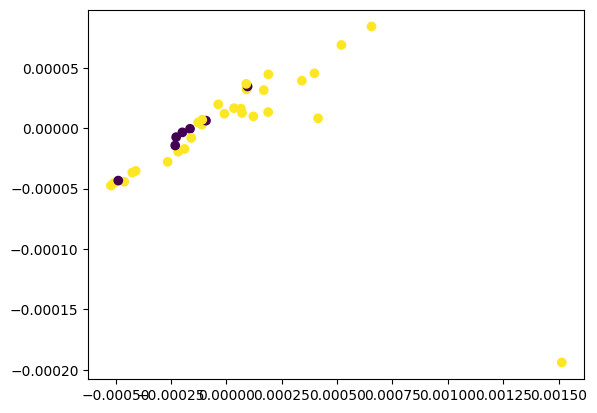

In [22]:
pca = PCA(n_components=2)
components = pca.fit_transform(np.mean(layer_outputs[:, -1, 0, :, :], axis=1))
plt.scatter(components[:, 0], components[:, 1], c=labels)

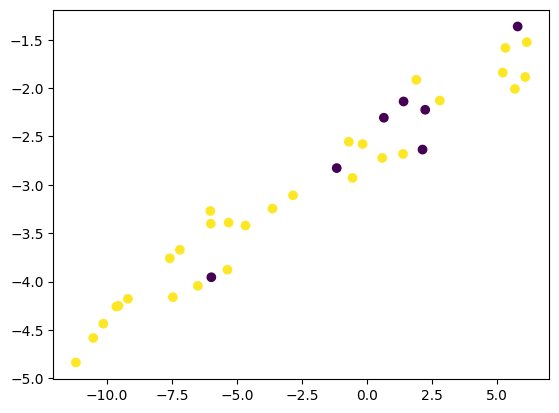

In [23]:
## TSNE

tsne = TSNE(n_components=2, perplexity=10, random_state=42)
tsne_res = tsne.fit_transform(np.mean(layer_outputs[:, -1, 0, :, :], axis=1))
plt.scatter(tsne_res[:, 0], tsne_res[:, 1], c=labels)
plt.show()

In [24]:
## UMAP
mapper = umap.UMAP().fit(np.mean(layer_outputs[:, -1, 0, :, :], axis=1))
umap.plot.points(mapper, labels=labels)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


: 